In [48]:
import sys

print(sys.version)
print(sys.executable)

3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
c:\Users\shafi\number-simplex-reproduction\.venv\Scripts\python.exe


In [49]:
from pathlib import Path

# Project root
ROOT = Path.cwd().parent

# Raw data for one subject/task
DATA_DIR = ROOT / "data" / "raw" / "YFF" / "arithmetic"

print("Project root:", ROOT)
print("Data directory:", DATA_DIR)
print("\nFiles:")
for file in DATA_DIR.iterdir():
    print(" -", file.name)

Project root: c:\Users\shafi\number-simplex-reproduction
Data directory: c:\Users\shafi\number-simplex-reproduction\data\raw\YFF\arithmetic

Files:
 - photoBehavEvents.csv
 - photoBehavEvents.mat
 - spikes.mat


In [50]:
import pandas as pd

behav_file = DATA_DIR / "photoBehavEvents.csv"

behav = pd.read_csv(behav_file)

print("Shape:", behav.shape)
print("\nColumn names:")
print(behav.columns.tolist())

behav.head()

Shape: (100, 22)

Column names:
['trial', 'tCue1', 'tCue2', 'tCue3', 'presentationEnd', 'tPress1', 'tPress2', 'tPress3', 'keyPress1', 'keyPress2', 'keyPress3', 'choiceEnd', 'timeFeedback', 'cue1', 'cue2', 'operation', 'operationFirst', 'correctAnsw', 'givenAnsw', 'correct', 'correctFb', 'toExclude']


,trial,tCue1,tCue2,tCue3,presentationEnd,tPress1,tPress2,tPress3,keyPress1,keyPress2,...,timeFeedback,cue1,cue2,operation,operationFirst,correctAnsw,givenAnsw,correct,correctFb,toExclude
0,1,5338.733333,6089.466667,6840.200000,7607.600000,13830.233333,14030.500000,NaN,1,1.0,...,15398.433333,5,16,-,1,-11,11,0,1,0
1,2,15882.233333,16632.933333,17383.666667,18167.733333,20453.266667,NaN,NaN,3,NaN,...,21938.033333,2,1,+,0,3,3,1,1,0
2,3,22438.533333,23189.233333,23939.966667,24690.666667,26192.133333,NaN,NaN,7,NaN,...,27576.766667,6,1,+,1,7,7,1,1,0
3,4,28077.300000,28828.000000,29578.700000,30329.433333,34967.200000,35250.833333,NaN,2,1.0,...,36635.466667,0,16,+,0,16,21,0,1,0
4,5,37136.000000,37886.700000,38637.400000,39388.133333,40872.900000,41256.600000,NaN,1,6.0,...,42607.900000,10,6,+,0,16,16,1,1,0


In [51]:
print("operation:")
print(behav["operation"].value_counts(dropna=False))

print("\noperationFirst:")
print(behav["operationFirst"].value_counts(dropna=False))

print("\ncorrect:")
print(behav["correct"].value_counts(dropna=False))

print("\ntoExclude:")
print(behav["toExclude"].value_counts(dropna=False))

print("\ncue1 values:")
print(sorted(behav["cue1"].unique()))

print("\ncue2 values:")
print(sorted(behav["cue2"].unique()))

operation:
operation
+    51
-    49
Name: count, dtype: int64

operationFirst:
operationFirst
0    57
1    43
Name: count, dtype: int64

correct:
correct
1    84
0    16
Name: count, dtype: int64

toExclude:
toExclude
0    100
Name: count, dtype: int64

cue1 values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]

cue2 values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]


In [52]:
cols = [
    "trial",
    "tCue1",
    "tCue2",
    "tCue3",
    "cue1",
    "cue2",
    "operation",
    "operationFirst",
    "correctAnsw",
    "givenAnsw",
    "correct"
]

behav[cols].head(10)

,trial,tCue1,tCue2,tCue3,cue1,cue2,operation,operationFirst,correctAnsw,givenAnsw,correct
0,1,5338.733333,6089.466667,6840.200000,5,16,-,1,-11,11,0
1,2,15882.233333,16632.933333,17383.666667,2,1,+,0,3,3,1
2,3,22438.533333,23189.233333,23939.966667,6,1,+,1,7,7,1
3,4,28077.300000,28828.000000,29578.700000,0,16,+,0,16,21,0
4,5,37136.000000,37886.700000,38637.400000,10,6,+,0,16,16,1
5,6,43108.400000,43859.100000,44609.800000,9,8,-,0,1,1,1
6,7,49247.600000,49998.333333,50749.033333,5,15,-,1,-10,10,0
7,8,58206.233333,58956.933333,59707.633333,8,1,+,0,9,9,1
8,9,64245.366667,64996.066667,65746.766667,9,1,+,0,10,10,1
9,10,70885.066667,71635.766667,72386.500000,0,16,-,0,-16,16,0


In [53]:
# Keep only the columns we need for constructing operand presentations
operand_data = behav[
    ["trial", "cue1", "cue2", "operationFirst", "tCue1", "tCue2", "tCue3"]
].copy()

# Determine when operand 1 and operand 2 appeared
operand_data["operand1_onset"] = operand_data["tCue1"]
operand_data["operand2_onset"] = operand_data["tCue2"]

mask = operand_data["operationFirst"] == 1

operand_data.loc[mask, "operand1_onset"] = operand_data.loc[mask, "tCue2"]
operand_data.loc[mask, "operand2_onset"] = operand_data.loc[mask, "tCue3"]

operand_data.head(10)

,trial,cue1,cue2,operationFirst,tCue1,tCue2,tCue3,operand1_onset,operand2_onset
0,1,5,16,1,5338.733333,6089.466667,6840.200000,6089.466667,6840.200000
1,2,2,1,0,15882.233333,16632.933333,17383.666667,15882.233333,16632.933333
2,3,6,1,1,22438.533333,23189.233333,23939.966667,23189.233333,23939.966667
3,4,0,16,0,28077.300000,28828.000000,29578.700000,28077.300000,28828.000000
4,5,10,6,0,37136.000000,37886.700000,38637.400000,37136.000000,37886.700000
5,6,9,8,0,43108.400000,43859.100000,44609.800000,43108.400000,43859.100000
6,7,5,15,1,49247.600000,49998.333333,50749.033333,49998.333333,50749.033333
7,8,8,1,0,58206.233333,58956.933333,59707.633333,58206.233333,58956.933333
8,9,9,1,0,64245.366667,64996.066667,65746.766667,64245.366667,64996.066667
9,10,0,16,0,70885.066667,71635.766667,72386.500000,70885.066667,71635.766667


In [54]:
# Operand 1 presentations
op1 = operand_data[
    ["trial", "cue1", "operand1_onset"]
].copy()

op1.columns = ["trial", "number", "onset"]
op1["operand"] = 1


# Operand 2 presentations
op2 = operand_data[
    ["trial", "cue2", "operand2_onset"]
].copy()

op2.columns = ["trial", "number", "onset"]
op2["operand"] = 2


# Pool the two operands
presentations = pd.concat([op1, op2], ignore_index=True)

print("Before filtering:", len(presentations))

presentations.head(10)

Before filtering: 200


,trial,number,onset,operand
0,1,5,6089.466667,1
1,2,2,15882.233333,1
2,3,6,23189.233333,1
3,4,0,28077.300000,1
4,5,10,37136.000000,1
5,6,9,43108.400000,1
6,7,5,49998.333333,1
7,8,8,58206.233333,1
8,9,9,64245.366667,1
9,10,0,70885.066667,1


In [55]:
presentations_1to9 = presentations[
    presentations["number"].between(1, 9)
].copy()

print("Presentations before filtering:", len(presentations))
print("Presentations with numbers 1-9:", len(presentations_1to9))

print("\nCounts for each number:")
print(
    presentations_1to9["number"]
    .value_counts()
    .sort_index()
)

Presentations before filtering: 200
Presentations with numbers 1-9: 109

Counts for each number:
number
1    10
2    15
3    11
4     7
5     7
6    16
7    17
8    12
9    14
Name: count, dtype: int64


In [56]:
import h5py

spike_file = DATA_DIR / "spikes.mat"

with h5py.File(spike_file, "r") as f:
    print("Top-level contents:")
    for key in f.keys():
        print(key)

Top-level contents:
#refs#
regionsVect
spikes


In [57]:
with h5py.File(spike_file, "r") as f:
    spikes = f["spikes"]

    print("Object type:", type(spikes))

    print("\nAttributes:")
    for key, value in spikes.attrs.items():
        print(key, ":", value)

    print("\nObjects inside 'spikes':")
    for key in spikes.keys():
        obj = spikes[key]
        print(
            key,
            "| shape =", obj.shape,
            "| dtype =", obj.dtype
        )

Object type: <class 'h5py._hl.group.Group'>

Attributes:
MATLAB_class : b'logical'
MATLAB_int_decode : 1
MATLAB_sparse : 54

Objects inside 'spikes':
data | shape = (501537,) | dtype = uint8
ir | shape = (501537,) | dtype = uint64
jc | shape = (708277,) | dtype = uint64


In [58]:
with h5py.File(spike_file, "r") as f:
    regions = f["regionsVect"]

    print("Object type:", type(regions))
    print("Shape:", regions.shape)
    print("Data type:", regions.dtype)

    print("\nAttributes:")
    for key, value in regions.attrs.items():
        print(key, ":", value)

Object type: <class 'h5py._hl.dataset.Dataset'>
Shape: (1, 54)
Data type: object

Attributes:
MATLAB_class : b'cell'


In [59]:
with h5py.File(spike_file, "r") as f:
    regions = f["regionsVect"]

    region_names = []

    for ref in regions[0]:
        obj = f[ref]
        chars = obj[:].flatten()
        name = "".join(chr(int(c)) for c in chars)
        region_names.append(name)

print("Number of region labels:", len(region_names))
print(region_names)


Number of region labels: 54
['acc', 'acc', 'acc', 'acc', 'acc', 'acc', 'acc', 'acc', 'ent', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'acc', 'acc', 'acc', 'acc', 'acc', 'acc', 'acc', 'acc', 'acc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc', 'hpc']


In [60]:
import numpy as np
import scipy.sparse as sp

with h5py.File(spike_file, "r") as f:
    g = f["spikes"]

    data = g["data"][:]
    ir = g["ir"][:]
    jc = g["jc"][:]

    n_rows = int(g.attrs["MATLAB_sparse"])
    n_cols = len(jc) - 1

spikes_sparse = sp.csc_matrix(
    (data, ir, jc),
    shape=(n_rows, n_cols)
)

print("Spike matrix shape:", spikes_sparse.shape)
print("Number of stored spikes:", spikes_sparse.nnz)

neuron_row = 9

spike_samples = spikes_sparse.getrow(neuron_row).indices

print("\nRegion:", region_names[neuron_row])
print("Number of spikes for this neuron:", len(spike_samples))
print("First 20 spike sample indices:")
print(spike_samples[:20])

Spike matrix shape: (54, 708276)
Number of stored spikes: 501537

Region: hpc
Number of spikes for this neuron: 11873
First 20 spike sample indices:
[  38   61  130  350  405  420  474  516  612  768  780  874  896  998
 1106 1110 1147 1154 1242 1269]


In [61]:
onset = presentations.iloc[0]["onset"]

nearby_spikes = spike_samples[
    (spike_samples >= onset - 1000) &
    (spike_samples <= onset + 2000)
]

print("Number presented:", presentations.iloc[0]["number"])
print("Operand:", presentations.iloc[0]["operand"])
print("Onset:", onset)

print("\nSpike indices from 1000 before to 2000 after onset:")
print(nearby_spikes)

Number presented: 5.0
Operand: 1.0
Onset: 6089.46666666667

Spike indices from 1000 before to 2000 after onset:
[5097 5143 5194 5278 5339 5498 5503 5505 5516 5581 5656 5798 5818 5877
 5881 6051 6062 6072 6243 6400 6436 6463 6490 6522 6623 6637 6653 6675
 6751 6889 6915 6917 6934 7001 7143 7201 7232 7239 7242 7380 7409 7412
 7457 7461 7628 7661 7698 7719 7767 7774 7801 7807 8061]


In [62]:
onset = presentations.iloc[0]["onset"]

window_start = onset + 50
window_end = onset + 950

spikes_in_window = spike_samples[
    (spike_samples >= window_start) &
    (spike_samples < window_end)
]

spike_count = len(spikes_in_window)
firing_rate = spike_count / 0.9

print("Number presented:", presentations.iloc[0]["number"])
print("Onset:", onset)
print("Window:", window_start, "to", window_end, "ms")

print("\nSpikes in window:")
print(spikes_in_window)

print("\nSpike count:", spike_count)
print("Firing rate:", firing_rate, "Hz")

Number presented: 5.0
Onset: 6089.46666666667
Window: 6139.46666666667 to 7039.46666666667 ms

Spikes in window:
[6243 6400 6436 6463 6490 6522 6623 6637 6653 6675 6751 6889 6915 6917
 6934 7001]

Spike count: 16
Firing rate: 17.77777777777778 Hz


In [63]:
firing_rates = []

for _, row in presentations_1to9.iterrows():

    onset = row["onset"]

    window_start = onset + 50
    window_end = onset + 950

    count = np.sum(
        (spike_samples >= window_start) &
        (spike_samples < window_end)
    )

    rate = count / 0.9
    firing_rates.append(rate)

presentations_1to9["firing_rate"] = firing_rates

presentations_1to9.head(10)

,trial,number,onset,operand,firing_rate
0,1,5,6089.466667,1,17.777778
1,2,2,15882.233333,1,21.111111
2,3,6,23189.233333,1,16.666667
5,6,9,43108.400000,1,12.222222
6,7,5,49998.333333,1,18.888889
7,8,8,58206.233333,1,12.222222
8,9,9,64245.366667,1,13.333333
10,11,6,78142.033333,1,11.111111
11,12,1,86066.300000,1,16.666667
12,13,2,90971.033333,1,4.444444


In [64]:
presentations_1to9


,trial,number,onset,operand,firing_rate
0,1,5,6089.466667,1,17.777778
1,2,2,15882.233333,1,21.111111
2,3,6,23189.233333,1,16.666667
5,6,9,43108.400000,1,12.222222
6,7,5,49998.333333,1,18.888889
...,...,...,...,...,...
190,91,7,650875.500000,2,25.555556
192,93,2,661502.366667,2,23.333333
194,95,1,674648.333333,2,12.222222
196,97,2,685408.666667,2,21.111111


In [65]:
tuning = (
    presentations_1to9
    .groupby("number")["firing_rate"]
    .agg(["count", "mean", "std"])
)

tuning["sem"] = tuning["std"] / np.sqrt(tuning["count"])

tuning

,count,mean,std,sem
number,,,,
1,10,15.444444,3.970053,1.255441
2,15,18.518519,5.978602,1.543668
3,11,16.060606,3.561233,1.073752
4,7,14.444444,4.885521,1.846553
5,7,17.460317,1.533479,0.579601
6,16,16.597222,4.005526,1.001382
7,17,17.581699,5.389681,1.307190
8,12,16.574074,4.888391,1.411157
9,14,15.793651,5.481187,1.464909


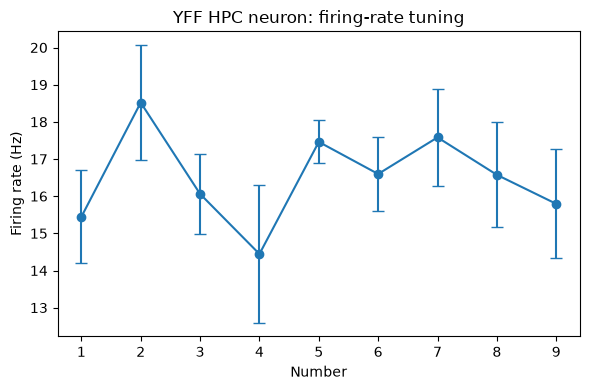

In [66]:
import matplotlib.pyplot as plt

numbers = tuning.index.to_numpy()
mean_fr = tuning["mean"].to_numpy()
sem_fr = tuning["sem"].to_numpy()

plt.figure(figsize=(6, 4))

plt.errorbar(
    numbers,
    mean_fr,
    yerr=sem_fr,
    fmt="o-",
    capsize=4
)

plt.xticks(range(1, 10))
plt.xlabel("Number")
plt.ylabel("Firing rate (Hz)")
plt.title("YFF HPC neuron: firing-rate tuning")

plt.tight_layout()
plt.show()

In [67]:
YFU_DIR = ROOT / "data" / "raw" / "YFU" / "arithmetic"

print("YFU arithmetic files:")
for file in YFU_DIR.iterdir():
    print(" -", file.name)

YFU arithmetic files:
 - photoBehavEvents.csv
 - photoBehavEvents.mat
 - spikes.mat


In [68]:
with h5py.File(YFU_DIR / "spikes.mat", "r") as f:
    spikes_yfu = f["spikes"]

    print("Number of neural rows:",
          int(spikes_yfu.attrs["MATLAB_sparse"]))

    print("Number of time columns:",
          len(spikes_yfu["jc"]) - 1)

    # Decode region labels
    regions_yfu = f["regionsVect"]

    region_names_yfu = []

    for ref in regions_yfu[0]:
        obj = f[ref]
        chars = obj[:].flatten()
        name = "".join(chr(int(c)) for c in chars)
        region_names_yfu.append(name)

print("\nNumber of region labels:", len(region_names_yfu))

print("\nRegion counts:")
from collections import Counter
print(Counter(region_names_yfu))

Number of neural rows: 78
Number of time columns: 2273935

Number of region labels: 78

Region counts:
Counter({'hpc': 39, 'amy': 23, 'acc': 16})


In [69]:
print("HPC rows:")

for python_row, region in enumerate(region_names_yfu):
    if region == "hpc":
        print(
            "Python row =", python_row,
            "| MATLAB row =", python_row + 1
        )

HPC rows:
Python row = 20 | MATLAB row = 21
Python row = 21 | MATLAB row = 22
Python row = 22 | MATLAB row = 23
Python row = 23 | MATLAB row = 24
Python row = 24 | MATLAB row = 25
Python row = 25 | MATLAB row = 26
Python row = 26 | MATLAB row = 27
Python row = 27 | MATLAB row = 28
Python row = 28 | MATLAB row = 29
Python row = 29 | MATLAB row = 30
Python row = 30 | MATLAB row = 31
Python row = 31 | MATLAB row = 32
Python row = 32 | MATLAB row = 33
Python row = 33 | MATLAB row = 34
Python row = 34 | MATLAB row = 35
Python row = 35 | MATLAB row = 36
Python row = 36 | MATLAB row = 37
Python row = 37 | MATLAB row = 38
Python row = 38 | MATLAB row = 39
Python row = 39 | MATLAB row = 40
Python row = 40 | MATLAB row = 41
Python row = 41 | MATLAB row = 42
Python row = 42 | MATLAB row = 43
Python row = 54 | MATLAB row = 55
Python row = 55 | MATLAB row = 56
Python row = 56 | MATLAB row = 57
Python row = 57 | MATLAB row = 58
Python row = 58 | MATLAB row = 59
Python row = 59 | MATLAB row = 60
Pyth

In [70]:
import pandas as pd

behav_yfu = pd.read_csv(YFU_DIR / "photoBehavEvents.csv")

print("Shape:", behav_yfu.shape)

print("\nColumns:")
print(behav_yfu.columns.tolist())

print("\noperationFirst:")
print(behav_yfu["operationFirst"].value_counts())

print("\ntoExclude:")
print(behav_yfu["toExclude"].value_counts())

behav_yfu.head()

Shape: (300, 22)

Columns:
['trial', 'tCue1', 'tCue2', 'tCue3', 'presentationEnd', 'tPress1', 'tPress2', 'tPress3', 'keyPress1', 'keyPress2', 'keyPress3', 'choiceEnd', 'timeFeedback', 'cue1', 'cue2', 'operation', 'operationFirst', 'correctAnsw', 'givenAnsw', 'correct', 'correctFb', 'toExclude']

operationFirst:
operationFirst
0    161
1    139
Name: count, dtype: int64

toExclude:
toExclude
0    300
Name: count, dtype: int64


,trial,tCue1,tCue2,tCue3,presentationEnd,tPress1,tPress2,tPress3,keyPress1,keyPress2,...,timeFeedback,cue1,cue2,operation,operationFirst,correctAnsw,givenAnsw,correct,correctFb,toExclude
0,1,5910.833333,6660.833333,7410.800000,8177.466667,72843.066667,78309.633333,NaN,Home,5.0,...,80876.233333,7,8,-,1,-1,5,0,1,0
1,2,81376.233333,82126.233333,82876.233333,83626.200000,86309.500000,86642.800000,NaN,1,1.0,...,88376.100000,7,4,+,0,11,11,1,1,0
2,3,88876.133333,89626.100000,90376.100000,91126.066667,94109.366667,NaN,NaN,1,NaN,...,95592.666667,7,6,-,1,1,1,1,1,0
3,4,96092.666667,96842.633333,97592.633333,98342.633333,104792.500000,105425.833333,113942.366667,1,5.0,...,118208.933333,10,5,-,1,5,15,0,1,0
4,5,118708.933333,119458.933333,120208.933333,120958.900000,122258.900000,NaN,NaN,0,NaN,...,123392.200000,8,0,-,0,8,0,0,1,0


In [71]:
import numpy as np

operand_yfu = behav_yfu.copy()

operand_yfu["operand1_onset"] = np.where(
    operand_yfu["operationFirst"] == 1,
    operand_yfu["tCue2"],
    operand_yfu["tCue1"]
)

operand_yfu["operand2_onset"] = np.where(
    operand_yfu["operationFirst"] == 1,
    operand_yfu["tCue3"],
    operand_yfu["tCue2"]
)

operand_yfu[
    [
        "trial", "cue1", "cue2", "operation",
        "operationFirst",
        "tCue1", "tCue2", "tCue3",
        "operand1_onset", "operand2_onset"
    ]
].head(10)

,trial,cue1,cue2,operation,operationFirst,tCue1,tCue2,tCue3,operand1_onset,operand2_onset
0,1,7,8,-,1,5910.833333,6660.833333,7410.800000,6660.833333,7410.800000
1,2,7,4,+,0,81376.233333,82126.233333,82876.233333,81376.233333,82126.233333
2,3,7,6,-,1,88876.133333,89626.100000,90376.100000,89626.100000,90376.100000
3,4,10,5,-,1,96092.666667,96842.633333,97592.633333,96842.633333,97592.633333
4,5,8,0,-,0,118708.933333,119458.933333,120208.933333,118708.933333,119458.933333
5,6,4,4,+,1,123892.200000,124642.166667,125392.166667,124642.166667,125392.166667
6,7,10,2,+,1,129525.433333,130275.433333,131025.400000,130275.433333,131025.400000
7,8,7,3,-,1,135025.333333,135775.333333,136525.300000,135775.333333,136525.300000
8,9,3,2,-,0,143491.866667,144241.833333,144991.833333,143491.866667,144241.833333
9,10,4,4,+,0,148841.766667,149575.100000,150341.733333,148841.766667,149575.100000


In [72]:
# Operand 1 presentations
op1_yfu = operand_yfu[
    ["trial", "cue1", "operand1_onset"]
].copy()

op1_yfu.columns = ["trial", "number", "onset"]
op1_yfu["operand"] = 1


# Operand 2 presentations
op2_yfu = operand_yfu[
    ["trial", "cue2", "operand2_onset"]
].copy()

op2_yfu.columns = ["trial", "number", "onset"]
op2_yfu["operand"] = 2


# Pool both operands
presentations_yfu = pd.concat(
    [op1_yfu, op2_yfu],
    ignore_index=True
)


# Keep numbers 1–9
presentations_yfu_1to9 = presentations_yfu[
    presentations_yfu["number"].between(1, 9)
].copy()


print("Total operand presentations:", len(presentations_yfu))
print("Presentations of numbers 1–9:", len(presentations_yfu_1to9))

print("\nCounts per number:")
print(
    presentations_yfu_1to9["number"]
    .value_counts()
    .sort_index()
)

Total operand presentations: 600
Presentations of numbers 1–9: 494

Counts per number:
number
1    53
2    67
3    52
4    62
5    51
6    48
7    65
8    49
9    47
Name: count, dtype: int64


In [73]:
import h5py
import scipy.sparse as sp

spike_file_yfu = YFU_DIR / "spikes.mat"

with h5py.File(spike_file_yfu, "r") as f:
    g = f["spikes"]

    data = g["data"][:]
    ir   = g["ir"][:]
    jc   = g["jc"][:]

    n_rows = int(g.attrs["MATLAB_sparse"])
    n_cols = len(jc) - 1

spikes_yfu_sparse = sp.csc_matrix(
    (data, ir, jc),
    shape=(n_rows, n_cols)
)

# YFU.hpc.43
neuron_row = 42

# Find all time indices at which this neuron fired
spike_samples_yfu = spikes_yfu_sparse.getrow(neuron_row).indices

print("Region:", region_names_yfu[neuron_row])
print("Python row:", neuron_row)
print("MATLAB row:", neuron_row + 1)
print("Total spikes:", len(spike_samples_yfu))

print("\nFirst 20 spike times:")
print(spike_samples_yfu[:20])

Region: hpc
Python row: 42
MATLAB row: 43
Total spikes: 15270

First 20 spike times:
[ 156  242  331  411  455  507 1346 1567 1696 1702 1825 1965 2259 2737
 2851 2913 2915 3086 3233 3419]


In [74]:
# Take the first number 1–9 presentation
example = presentations_yfu_1to9.iloc[0]

number = example["number"]
onset = example["onset"]

# Paper's arithmetic analysis window
window_start = onset + 50
window_end   = onset + 950

# Spikes from YFU.hpc.43 inside this window
spikes_in_window = spike_samples_yfu[
    (spike_samples_yfu >= window_start) &
    (spike_samples_yfu < window_end)
]

spike_count = len(spikes_in_window)
firing_rate = spike_count / 0.9

print("Number:", number)
print("Operand:", example["operand"])
print("Onset:", onset)

print("\nAnalysis window:")
print(window_start, "to", window_end, "ms")

print("\nSpikes in window:")
print(spikes_in_window)

print("\nSpike count:", spike_count)
print("Firing rate:", firing_rate, "Hz")

Number: 7.0
Operand: 1.0
Onset: 6660.83333333333

Analysis window:
6710.83333333333 to 7610.83333333333 ms

Spikes in window:
[6794 6927 7500 7510 7597 7599]

Spike count: 6
Firing rate: 6.666666666666666 Hz


In [75]:
firing_rates_yfu = []

for _, row in presentations_yfu_1to9.iterrows():

    onset = row["onset"]

    # 50–950 ms after operand onset
    window_start = onset + 50
    window_end   = onset + 950

    spike_count = np.sum(
        (spike_samples_yfu >= window_start) &
        (spike_samples_yfu < window_end)
    )

    firing_rate = spike_count / 0.9

    firing_rates_yfu.append(firing_rate)


presentations_yfu_1to9["firing_rate"] = firing_rates_yfu

In [76]:
tuning_yfu = (
    presentations_yfu_1to9
    .groupby("number")["firing_rate"]
    .agg(["count", "mean", "std"])
)

tuning_yfu["sem"] = (
    tuning_yfu["std"] /
    np.sqrt(tuning_yfu["count"])
)

tuning_yfu

,count,mean,std,sem
number,,,,
1,53,6.498952,2.725109,0.374323
2,67,6.766169,2.706018,0.330593
3,52,7.307692,3.003638,0.416530
4,62,6.308244,2.836531,0.360240
5,51,7.189542,2.857547,0.400137
6,48,7.129630,2.720046,0.392605
7,65,6.034188,2.484281,0.308137
8,49,6.190476,2.585970,0.369424
9,47,7.092199,2.447003,0.356932


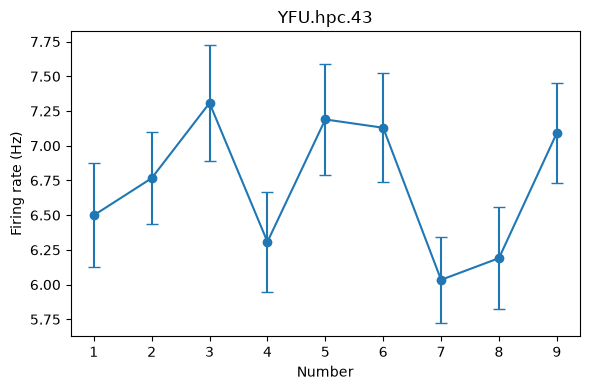

In [77]:
import matplotlib.pyplot as plt

numbers = tuning_yfu.index.to_numpy()
mean_fr = tuning_yfu["mean"].to_numpy()
sem_fr  = tuning_yfu["sem"].to_numpy()

plt.figure(figsize=(6, 4))

plt.errorbar(
    numbers,
    mean_fr,
    yerr=sem_fr,
    fmt="o-",
    capsize=4
)

plt.xticks(range(1, 10))

plt.xlabel("Number")
plt.ylabel("Firing rate (Hz)")
plt.title("YFU.hpc.43")

plt.tight_layout()
plt.show()

In [78]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.firing_rate_tuning import analyze_neuron

Subject: YFU

Total recorded neurons: 78

All recorded regions:
  acc: 16
  amy: 23
  hpc: 39

MTL regions used in paper:
  amy: 23
  hpc: 39

Total MTL neurons: 62

Selected neuron:
  MATLAB row: 43
  Python row: 42
  Region: hpc
  Total spikes: 15270

Number presentation counts:
number
1    53
2    67
3    52
4    62
5    51
6    48
7    65
8    49
9    47
Name: count, dtype: int64

Firing-rate tuning:
        count      mean       std       sem
number                                     
1          53  6.498952  2.725109  0.374323
2          67  6.766169  2.706018  0.330593
3          52  7.307692  3.003638  0.416530
4          62  6.308244  2.836531  0.360240
5          51  7.189542  2.857547  0.400137
6          48  7.129630  2.720046  0.392605
7          65  6.034188  2.484281  0.308137
8          49  6.190476  2.585970  0.369424
9          47  7.092199  2.447003  0.356932


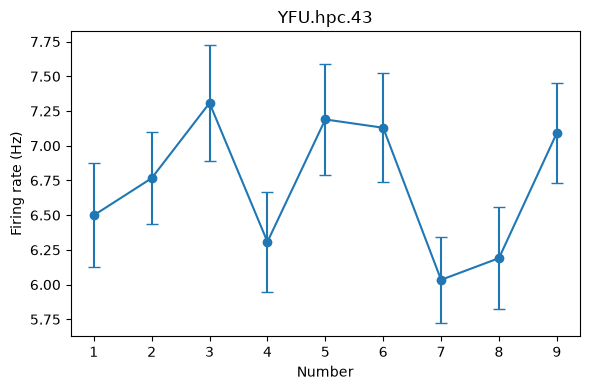

In [79]:
result = analyze_neuron(
    subject="YFU",
    neuron=43
)

Subject: YFS

Total recorded neurons: 96

All recorded regions:
  acc: 17
  amy: 22
  hpc: 37
  ofc: 9
  thal: 11

MTL regions used in paper:
  amy: 22
  hpc: 37

Total MTL neurons: 59

Selected neuron:
  MATLAB row: 27
  Python row: 26
  Region: amy
  Total spikes: 3054

Number presentation counts:
number
1    32
2    33
3    24
4    33
5    32
6    24
7    27
8    30
9    29
Name: count, dtype: int64

Firing-rate tuning:
        count      mean       std       sem
number                                     
1          32  1.180556  1.195288  0.211299
2          33  1.414141  1.085565  0.188973
3          24  1.481481  1.070096  0.218433
4          33  1.212121  1.222337  0.212782
5          32  1.388889  1.353492  0.239266
6          24  1.064815  1.060650  0.216504
7          27  1.358025  1.319491  0.253936
8          30  1.481481  1.214827  0.221796
9          29  1.264368  1.415589  0.262868


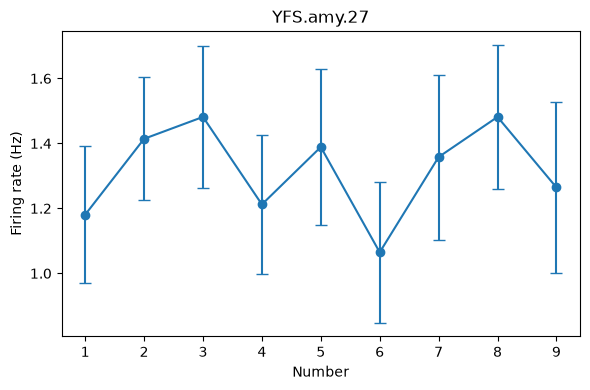

In [80]:
result = analyze_neuron(
    subject="YFS",
    neuron=27
)

Subject: YFS

Total recorded neurons: 96

All recorded regions:
  acc: 17
  amy: 22
  hpc: 37
  ofc: 9
  thal: 11

MTL regions used in paper:
  amy: 22
  hpc: 37

Total MTL neurons: 59

Selected neuron:
  MATLAB row: 38
  Python row: 37
  Region: hpc
  Total spikes: 13683

Number presentation counts:
number
1    32
2    33
3    24
4    33
5    32
6    24
7    27
8    30
9    29
Name: count, dtype: int64

Firing-rate tuning:
        count      mean       std       sem
number                                     
1          32  5.798611  2.597894  0.459247
2          33  5.050505  2.980012  0.518753
3          24  5.972222  3.541223  0.722849
4          33  5.488215  2.720796  0.473630
5          32  6.388889  3.421766  0.604888
6          24  5.925926  4.280386  0.873730
7          27  4.938272  2.250532  0.433115
8          30  5.592593  2.212302  0.403909
9          29  5.019157  2.441930  0.453455


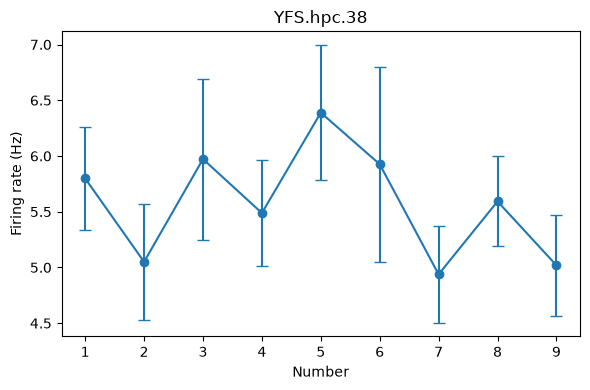

In [81]:
result = analyze_neuron(
    subject="YFS",
    neuron=38
)

Subject: YFT

Total recorded neurons: 89

All recorded regions:
  acc: 9
  amy: 8
  ent: 17
  hpc: 27
  ofc: 11
  thal: 17

MTL regions used in paper:
  amy: 8
  ent: 17
  hpc: 27

Total MTL neurons: 52

Selected neuron:
  MATLAB row: 50
  Python row: 49
  Region: hpc
  Total spikes: 24406

Number presentation counts:
number
1    62
2    48
3    52
4    57
5    53
6    56
7    43
8    50
9    56
Name: count, dtype: int64

Firing-rate tuning:
        count      mean       std       sem
number                                     
1          62  6.684588  3.054467  0.387918
2          48  7.060185  3.237305  0.467265
3          52  7.072650  2.877545  0.399044
4          57  7.407407  3.275513  0.433852
5          53  7.651992  3.373409  0.463373
6          56  7.976190  3.462852  0.462743
7          43  6.950904  3.463873  0.528236
8          50  8.022222  3.376814  0.477554
9          56  7.023810  2.967139  0.396501


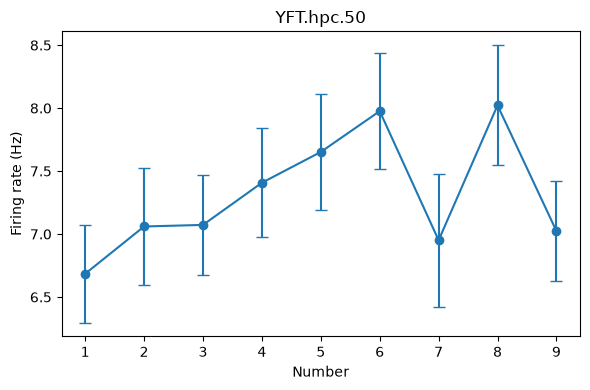

In [82]:
result = analyze_neuron(
    subject="YFT",
    neuron=50
)

Subject: YFT

Total recorded neurons: 89

All recorded regions:
  acc: 9
  amy: 8
  ent: 17
  hpc: 27
  ofc: 11
  thal: 17

MTL regions used in paper:
  amy: 8
  ent: 17
  hpc: 27

Total MTL neurons: 52

Selected neuron:
  MATLAB row: 77
  Python row: 76
  Region: ent
  Total spikes: 2710

Number presentation counts:
number
1    62
2    48
3    52
4    57
5    53
6    56
7    43
8    50
9    56
Name: count, dtype: int64

Firing-rate tuning:
        count      mean       std       sem
number                                     
1          62  0.645161  0.842803  0.107036
2          48  0.532407  0.724431  0.104563
3          52  0.790598  1.107544  0.153589
4          57  0.799220  0.859494  0.113843
5          53  0.566038  0.833266  0.114458
6          56  0.793651  0.812757  0.108609
7          43  0.723514  0.903443  0.137774
8          50  0.555556  0.847387  0.119839
9          56  0.615079  0.818409  0.109364


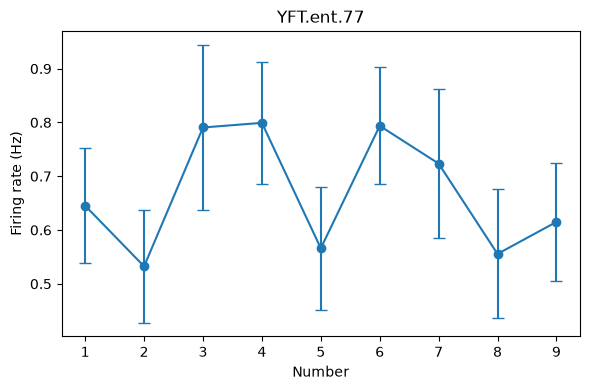

In [83]:
result = analyze_neuron(
    subject="YFT",
    neuron=77
)

Subject: YFU

Total recorded neurons: 78

All recorded regions:
  acc: 16
  amy: 23
  hpc: 39

MTL regions used in paper:
  amy: 23
  hpc: 39

Total MTL neurons: 62

Selected neuron:
  MATLAB row: 2
  Python row: 1
  Region: amy
  Total spikes: 33434

Number presentation counts:
number
1    53
2    67
3    52
4    62
5    51
6    48
7    65
8    49
9    47
Name: count, dtype: int64

Firing-rate tuning:
        count       mean       std       sem
number                                      
1          53  15.345912  3.347949  0.459876
2          67  15.422886  4.475992  0.546829
3          52  14.700855  4.060874  0.563142
4          62  14.964158  4.146272  0.526577
5          51  15.098039  4.122665  0.577289
6          48  13.958333  3.437354  0.496139
7          65  14.564103  4.106619  0.509363
8          49  13.696145  4.566539  0.652363
9          47  14.255319  3.407541  0.497041


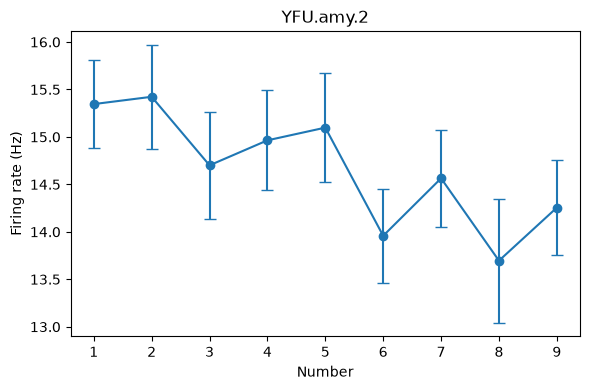

In [84]:
result = analyze_neuron(
    subject="YFU",
    neuron=2
)

Subject: YFU

Total recorded neurons: 78

All recorded regions:
  acc: 16
  amy: 23
  hpc: 39

MTL regions used in paper:
  amy: 23
  hpc: 39

Total MTL neurons: 62

Selected neuron:
  MATLAB row: 24
  Python row: 23
  Region: hpc
  Total spikes: 47657

Number presentation counts:
number
1    53
2    67
3    52
4    62
5    51
6    48
7    65
8    49
9    47
Name: count, dtype: int64

Firing-rate tuning:
        count       mean       std       sem
number                                      
1          53  20.440252  5.135115  0.705362
2          67  21.873964  6.193080  0.756605
3          52  21.987179  6.671518  0.925173
4          62  20.824373  6.022072  0.764804
5          51  21.895425  6.235280  0.873114
6          48  20.972222  5.579735  0.805365
7          65  20.871795  5.272264  0.653944
8          49  21.360544  8.105735  1.157962
9          47  21.867612  6.138963  0.895460


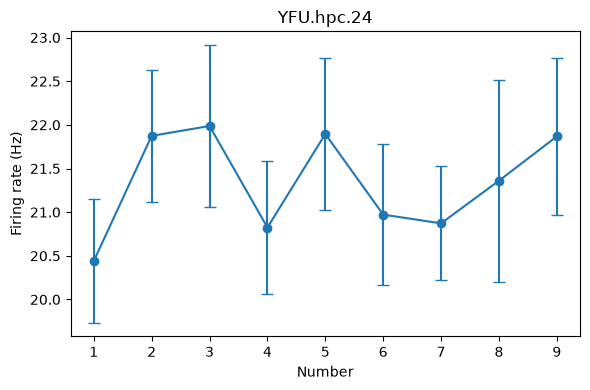

In [85]:
result = analyze_neuron(
    subject="YFU",
    neuron=24
)

In [86]:
result["presentations"]
result["spike_times"]

array([     75,     157,     220, ..., 2273907, 2273923, 2273925],
      shape=(47657,), dtype=int32)

In [87]:
result["presentations"]

,trial,number,onset,operand,spike_count,firing_rate
0,1,7,6.660833e+03,1,15,16.666667
1,2,7,8.137623e+04,1,14,15.555556
2,3,7,8.962610e+04,1,14,15.555556
4,5,8,1.187089e+05,1,24,26.666667
5,6,4,1.246422e+05,1,13,14.444444
...,...,...,...,...,...,...
593,294,4,2.230890e+06,2,24,26.666667
594,295,1,2.239890e+06,2,21,23.333333
595,296,8,2.244439e+06,2,18,20.000000
597,298,5,2.255223e+06,2,15,16.666667


------

Fig 1E Scatter plot of firing rate tuning for YFU.hpc.43 , SPIKE TRAINS 


Subject: YFU

Total recorded neurons: 78

All recorded regions:
  acc: 16
  amy: 23
  hpc: 39

MTL regions used in paper:
  amy: 23
  hpc: 39

Total MTL neurons: 62

Selected neuron:
  MATLAB row: 43
  Python row: 42
  Region: hpc
  Total spikes: 15270

Number presentation counts:
number
1    53
2    67
3    52
4    62
5    51
6    48
7    65
8    49
9    47
Name: count, dtype: int64

Firing-rate tuning:
        count      mean       std       sem
number                                     
1          53  6.498952  2.725109  0.374323
2          67  6.766169  2.706018  0.330593
3          52  7.307692  3.003638  0.416530
4          62  6.308244  2.836531  0.360240
5          51  7.189542  2.857547  0.400137
6          48  7.129630  2.720046  0.392605
7          65  6.034188  2.484281  0.308137
8          49  6.190476  2.585970  0.369424
9          47  7.092199  2.447003  0.356932


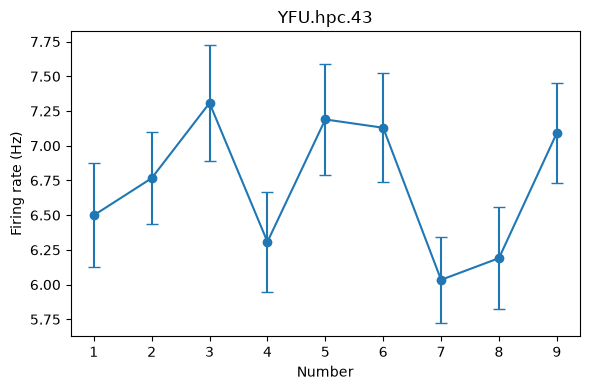

In [88]:
result = analyze_neuron("YFU", 43)

In [91]:
presentations = result["presentations"]
spike_times = result["spike_times"]

In [92]:
presentations_7 = presentations[
    presentations["number"] == 7
].copy()

print("Number of presentations of 7:", len(presentations_7))

Number of presentations of 7: 65


In [93]:
raster_7 = []

for _, row in presentations_7.iterrows():

    onset = row["onset"]

    # Find spikes from stimulus onset to 1000 ms afterward
    mask = (
        (spike_times >= onset) &
        (spike_times < onset + 1000)
    )

    absolute_spikes = spike_times[mask]

    # Align stimulus onset to t = 0
    relative_spikes = absolute_spikes - onset

    raster_7.append(relative_spikes)

In [94]:
for i in range(5):
    print(f"Presentation {i + 1}:")
    print(raster_7[i])
    print()

Presentation 1:
[ 20.16666667 133.16666667 266.16666667 839.16666667 849.16666667
 936.16666667 938.16666667]

Presentation 2:
[ 86.76666667 272.76666667 423.76666667 462.76666667 646.76666667
 796.76666667]

Presentation 3:
[ 49.9  55.9  58.9  73.9 633.9 654.9 727.9]

Presentation 4:
[  4.66666667 140.66666667 165.66666667 298.66666667 370.66666667
 987.66666667]

Presentation 5:
[ 80.83333333 367.83333333 826.83333333 834.83333333 855.83333333
 990.83333333]



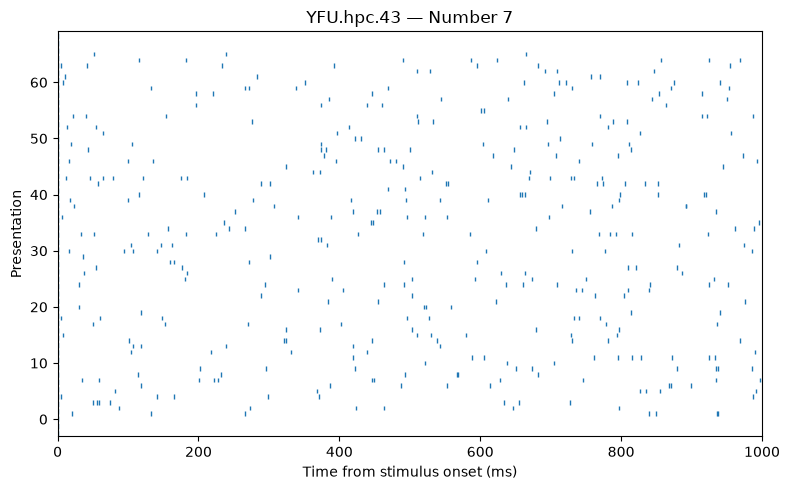

In [95]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.eventplot(
    raster_7,
    lineoffsets=range(1, len(raster_7) + 1),
    linelengths=0.8,
    linewidths=1
)

# Stimulus onset
ax.axvline(0, linestyle="--", linewidth=1)

ax.set_xlim(0, 1000)

ax.set_xlabel("Time from stimulus onset (ms)")
ax.set_ylabel("Presentation")
ax.set_title("YFU.hpc.43 — Number 7")

plt.tight_layout()
plt.show()

In [96]:
raster_by_number = {}

for number in range(1, 10):

    number_presentations = presentations[
        presentations["number"] == number
    ]

    spike_trains = []

    for _, row in number_presentations.iterrows():

        onset = row["onset"]

        mask = (
            (spike_times >= onset) &
            (spike_times < onset + 1000)
        )

        relative_spikes = spike_times[mask] - onset

        spike_trains.append(relative_spikes)

    raster_by_number[number] = spike_trains


# Check that the number of spike trains matches
# the number of presentations
for number in range(1, 10):
    print(
        f"Number {number}: "
        f"{len(raster_by_number[number])} spike trains"
    )

Number 1: 53 spike trains
Number 2: 67 spike trains
Number 3: 52 spike trains
Number 4: 62 spike trains
Number 5: 51 spike trains
Number 6: 48 spike trains
Number 7: 65 spike trains
Number 8: 49 spike trains
Number 9: 47 spike trains


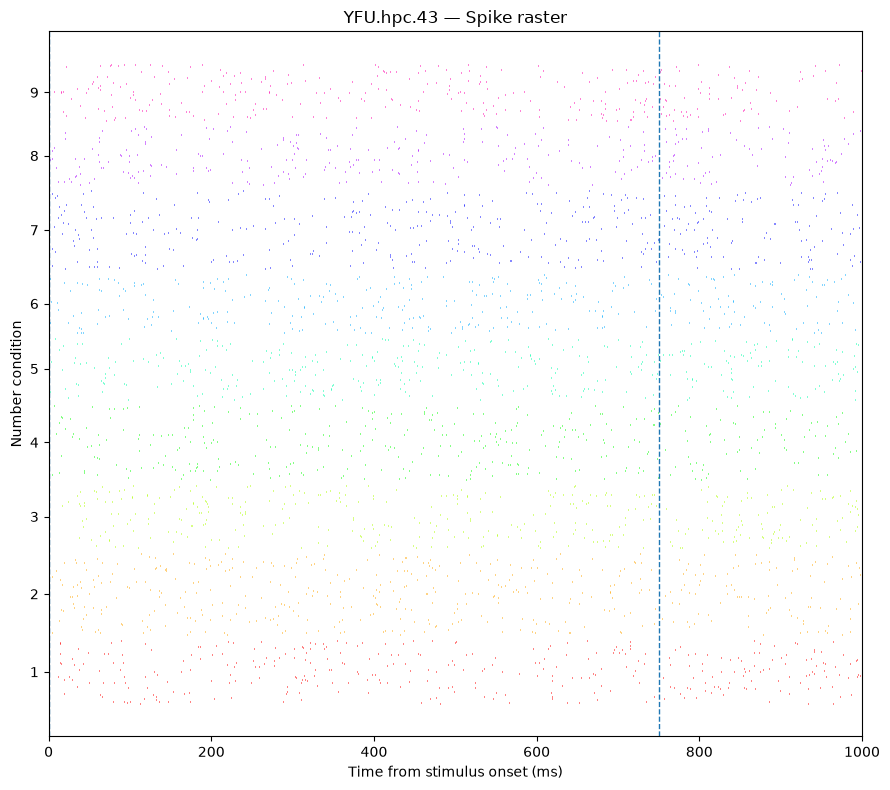

In [97]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 8))

# One color for each number
colors = plt.cm.hsv(np.linspace(0, 0.9, 9))

current_y = 0
number_centers = {}

# Start with 1 at bottom and build upward to 9
for number in range(1, 10):

    spike_trains = raster_by_number[number]

    n_trials = len(spike_trains)

    # y positions for this number's trials
    y_positions = np.arange(
        current_y,
        current_y + n_trials
    )

    ax.eventplot(
        spike_trains,
        lineoffsets=y_positions,
        linelengths=0.8,
        linewidths=0.7,
        colors=[colors[number - 1]],
    )

    # Middle of this block, used for number label
    number_centers[number] = (
        current_y + (n_trials - 1) / 2
    )

    # Leave a small gap between number conditions
    current_y += n_trials + 4


# Stimulus onset
ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

# Stimulus offset
ax.axvline(
    750,
    linestyle="--",
    linewidth=1
)

ax.set_xlim(0, 1000)

ax.set_yticks(
    [number_centers[n] for n in range(1, 10)]
)

ax.set_yticklabels(
    [str(n) for n in range(1, 10)]
)

ax.set_xlabel("Time from stimulus onset (ms)")
ax.set_ylabel("Number condition")

ax.set_title("YFU.hpc.43 — Spike raster")

plt.tight_layout()
plt.show()

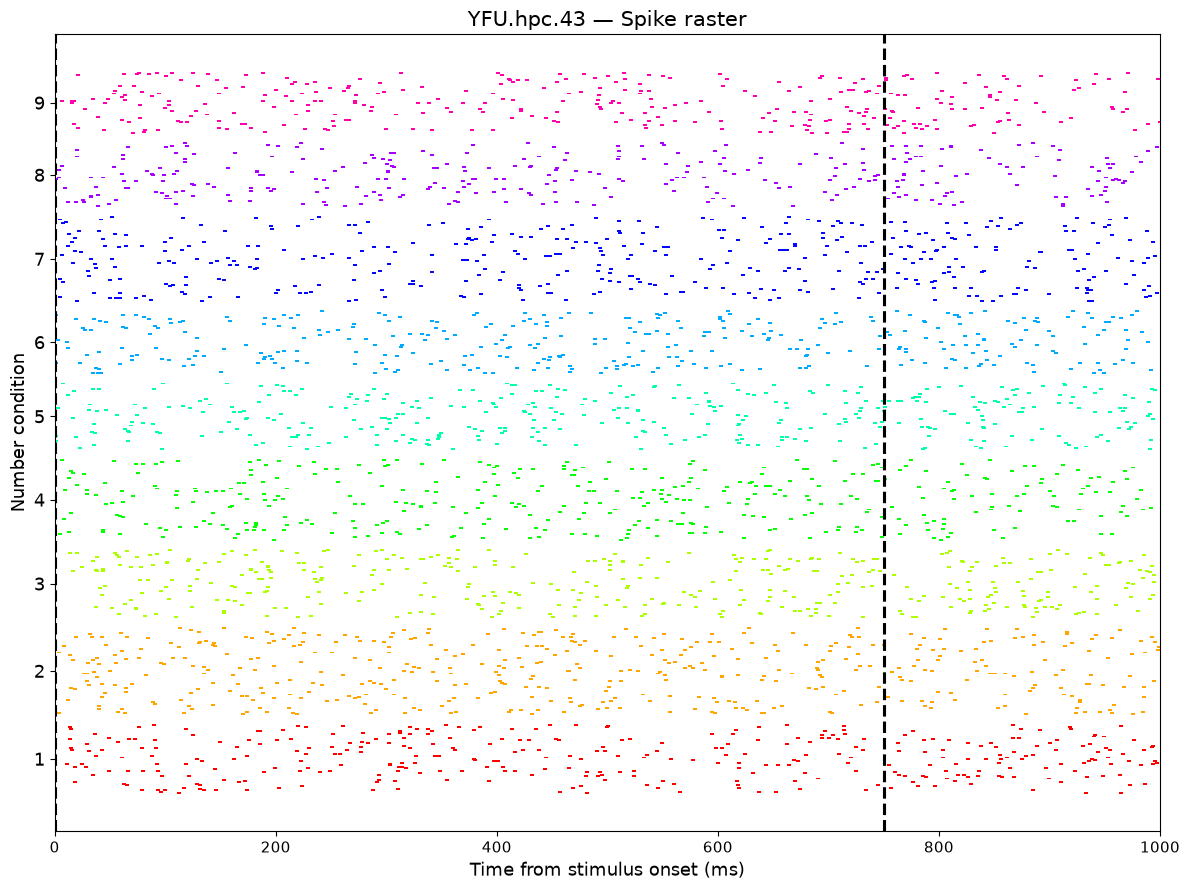

In [104]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 9))

# One color per number
colors = plt.cm.hsv(np.linspace(0, 0.9, 9))

current_y = 0
number_centers = {}

for number in range(1, 10):

    spike_trains = raster_by_number[number]
    n_trials = len(spike_trains)

    y_positions = np.arange(
        current_y,
        current_y + n_trials
    )

    ax.eventplot(
        spike_trains,
        lineoffsets=y_positions,

        # Make each spike mark taller
        linelengths=1.5,

        # Make each spike mark thicker
        linewidths=2.9,

        colors=[colors[number - 1]],
    )

    number_centers[number] = (
        current_y + (n_trials - 1) / 2
    )

    # Slightly larger gap between number groups
    current_y += n_trials + 7


# Stimulus onset
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2.23
)

# Stimulus offset
ax.axvline(
    750,
    color="black",
    linestyle="--",
    linewidth=2.23
)


ax.set_xlim(0, 1000)

ax.set_yticks(
    [number_centers[n] for n in range(1, 10)]
)

ax.set_yticklabels(
    [str(n) for n in range(1, 10)],
    fontsize=13
)

ax.set_xlabel(
    "Time from stimulus onset (ms)",
    fontsize=13
)

ax.set_ylabel(
    "Number condition",
    fontsize=13
)

ax.set_title(
    "YFU.hpc.43 — Spike raster",
    fontsize=15
)

ax.tick_params(axis="x", labelsize=11)

plt.tight_layout()
plt.show()

In [105]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Gaussian-smoothed firing rate for NUMBER 7
# --------------------------------------------------

sigma = 150.0       # Gaussian SD in milliseconds

# Plotting time grid.
# Include time before stimulus onset to reduce edge problems.
time = np.arange(-500, 1251, 1)   # 1-ms resolution

# Get all spike trains for number 7
spike_trains_7 = raster_by_number[7]

smoothed_trials_7 = []

for spikes in spike_trains_7:

    # IMPORTANT:
    # raster_by_number was originally constructed only from
    # 0–1000 ms spikes, so below we will improve this later
    # using the original spike_times to include pre-stimulus spikes.

    rate = np.zeros(len(time))

    for spike_time in spikes:

        # Gaussian centered on this spike
        gaussian = np.exp(
            -0.5 * ((time - spike_time) / sigma) ** 2
        )

        # Normalize Gaussian so its integral = 1 spike
        gaussian /= sigma * np.sqrt(2 * np.pi)

        # Convert spikes/ms -> spikes/sec = Hz
        gaussian *= 1000

        rate += gaussian

    smoothed_trials_7.append(rate)


smoothed_trials_7 = np.array(smoothed_trials_7)

print("Shape:", smoothed_trials_7.shape)

Shape: (65, 1751)


In [106]:
mean_7 = smoothed_trials_7.mean(axis=0)

sem_7 = (
    smoothed_trials_7.std(axis=0, ddof=1)
    / np.sqrt(smoothed_trials_7.shape[0])
)

In [108]:
mean_7, sem_7

(array([0.00348174, 0.0035652 , 0.00365051, ..., 0.32204886, 0.31763822,
        0.3132761 ], shape=(1751,)),
 array([0.00052285, 0.00053517, 0.00054776, ..., 0.04109829, 0.04057274,
        0.04005235], shape=(1751,)))

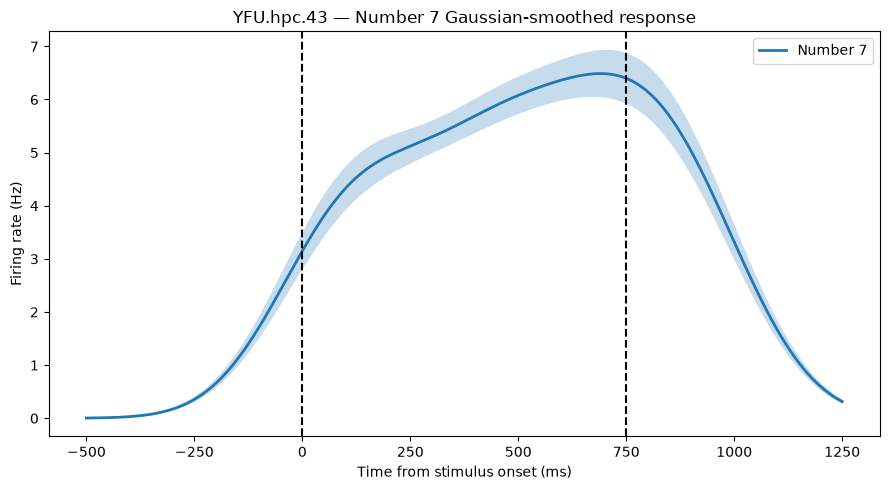

In [109]:
fig, ax = plt.subplots(figsize=(9, 5))

# Mean
ax.plot(
    time,
    mean_7,
    linewidth=2,
    label="Number 7"
)

# SEM
ax.fill_between(
    time,
    mean_7 - sem_7,
    mean_7 + sem_7,
    alpha=0.25
)

# Stimulus ON
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

# Stimulus OFF
ax.axvline(
    750,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax.set_xlabel("Time from stimulus onset (ms)")
ax.set_ylabel("Firing rate (Hz)")
ax.set_title("YFU.hpc.43 — Number 7 Gaussian-smoothed response")

ax.legend()

plt.tight_layout()
plt.show()

Instead, at every time point, we average the 65 curves.

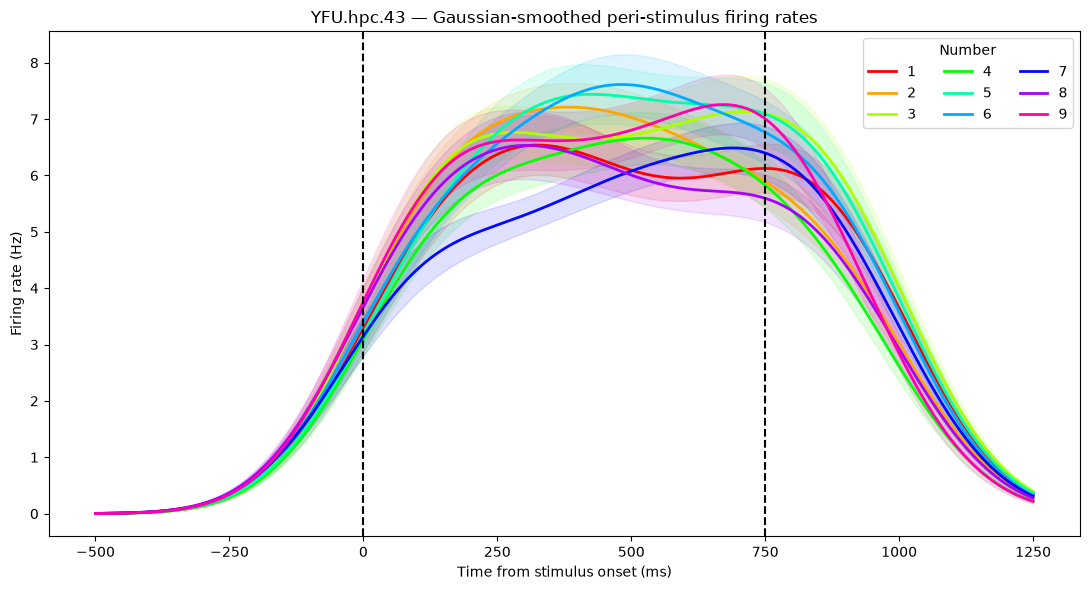

In [110]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Gaussian smoothing for ALL numbers 1–9
# --------------------------------------------------

sigma = 150.0  # ms

# 1-ms time grid
time = np.arange(-500, 1251, 1)

mean_by_number = {}
sem_by_number = {}
smoothed_by_number = {}


for number in range(1, 10):

    spike_trains = raster_by_number[number]

    smoothed_trials = []

    # ----------------------------------------------
    # Smooth every presentation separately
    # ----------------------------------------------
    for spikes in spike_trains:

        rate = np.zeros(len(time))

        for spike_time in spikes:

            gaussian = np.exp(
                -0.5 * ((time - spike_time) / sigma) ** 2
            )

            # Normalize Gaussian
            gaussian /= sigma * np.sqrt(2 * np.pi)

            # spikes/ms -> spikes/sec = Hz
            gaussian *= 1000

            rate += gaussian

        smoothed_trials.append(rate)


    smoothed_trials = np.array(smoothed_trials)

    # Save all trial curves
    smoothed_by_number[number] = smoothed_trials

    # ----------------------------------------------
    # Mean curve
    # ----------------------------------------------
    mean_by_number[number] = (
        smoothed_trials.mean(axis=0)
    )

    # ----------------------------------------------
    # SEM curve
    # ----------------------------------------------
    sem_by_number[number] = (
        smoothed_trials.std(axis=0, ddof=1)
        / np.sqrt(smoothed_trials.shape[0])
    )


# --------------------------------------------------
# Plot all nine numbers
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

colors = plt.cm.hsv(np.linspace(0, 0.9, 9))


for number in range(1, 10):

    mean = mean_by_number[number]
    sem = sem_by_number[number]

    ax.plot(
        time,
        mean,
        linewidth=2,
        color=colors[number - 1],
        label=str(number)
    )

    ax.fill_between(
        time,
        mean - sem,
        mean + sem,
        color=colors[number - 1],
        alpha=0.12
    )


# Stimulus ON
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

# Stimulus OFF
ax.axvline(
    750,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax.set_xlabel("Time from stimulus onset (ms)")
ax.set_ylabel("Firing rate (Hz)")

ax.set_title(
    "YFU.hpc.43 — Gaussian-smoothed peri-stimulus firing rates"
)

ax.legend(
    title="Number",
    ncol=3
)

plt.tight_layout()
plt.show()

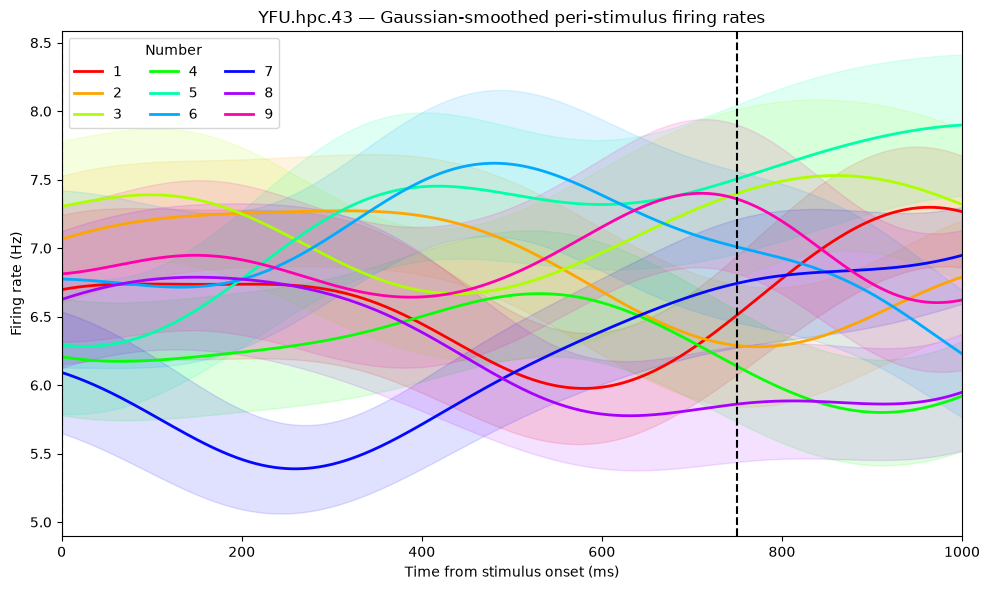

In [111]:
import numpy as np
import matplotlib.pyplot as plt

sigma = 150.0  # ms

# Figure 1F display interval
time = np.arange(0, 1001, 1)

# Because sigma = 150 ms, include spikes well outside
# the displayed interval when doing the convolution.
padding = 4 * sigma   # 600 ms

mean_by_number = {}
sem_by_number = {}
smoothed_by_number = {}

for number in range(1, 10):

    number_presentations = presentations[
        presentations["number"] == number
    ]

    smoothed_trials = []

    for _, row in number_presentations.iterrows():

        onset = row["onset"]

        # --------------------------------------------------
        # IMPORTANT:
        # use ORIGINAL spike times, including spikes outside
        # the displayed 0–1000 ms interval
        # --------------------------------------------------

        mask = (
            (spike_times >= onset - padding)
            &
            (spike_times <= onset + 1000 + padding)
        )

        relative_spikes = spike_times[mask] - onset

        rate = np.zeros(len(time))

        # Gaussian convolution
        for spike_time in relative_spikes:

            gaussian = np.exp(
                -0.5 * ((time - spike_time) / sigma) ** 2
            )

            gaussian /= (
                sigma * np.sqrt(2 * np.pi)
            )

            # spikes/ms -> Hz
            gaussian *= 1000

            rate += gaussian

        smoothed_trials.append(rate)

    smoothed_trials = np.array(smoothed_trials)

    smoothed_by_number[number] = smoothed_trials

    mean_by_number[number] = (
        smoothed_trials.mean(axis=0)
    )

    sem_by_number[number] = (
        smoothed_trials.std(axis=0, ddof=1)
        / np.sqrt(smoothed_trials.shape[0])
    )


# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.hsv(np.linspace(0, 0.9, 9))

for number in range(1, 10):

    mean = mean_by_number[number]
    sem = sem_by_number[number]

    ax.plot(
        time,
        mean,
        linewidth=2,
        color=colors[number - 1],
        label=str(number)
    )

    ax.fill_between(
        time,
        mean - sem,
        mean + sem,
        color=colors[number - 1],
        alpha=0.12
    )


# Stimulus onset
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

# Stimulus offset
ax.axvline(
    750,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax.set_xlim(0, 1000)

ax.set_xlabel("Time from stimulus onset (ms)")
ax.set_ylabel("Firing rate (Hz)")

ax.set_title(
    "YFU.hpc.43 — Gaussian-smoothed peri-stimulus firing rates"
)

ax.legend(
    title="Number",
    ncol=3
)

plt.tight_layout()
plt.show()

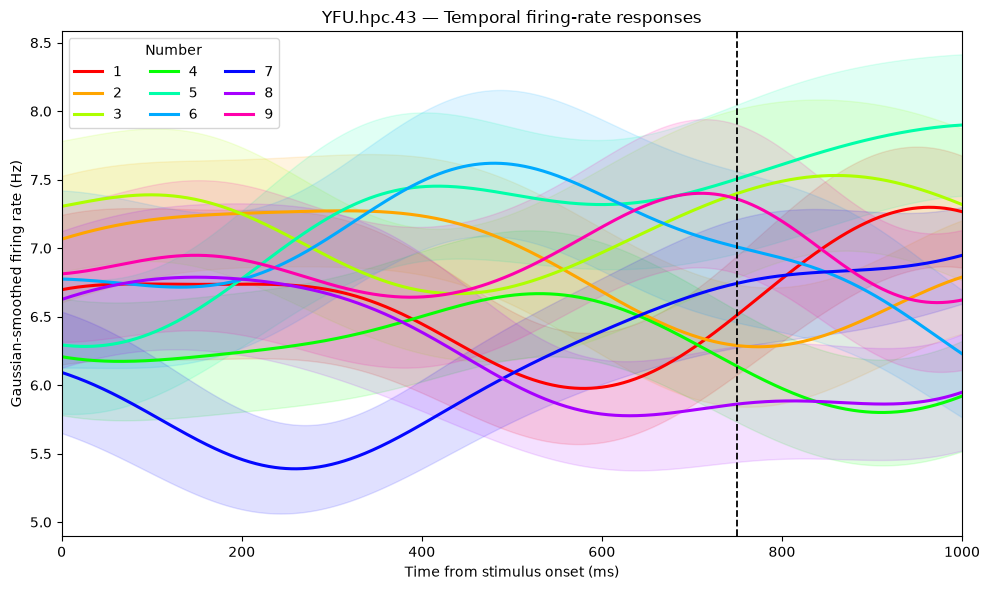

In [114]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Figure 1F-style Gaussian-smoothed temporal firing rates
# ============================================================

sigma = 150.0       # ms, as stated in the paper
time = np.arange(0, 1001, 1)   # display 0–1000 ms
padding = 600       # 4 sigma, avoids edge artifacts

mean_by_number = {}
sem_by_number = {}


for number in range(1, 10):

    # All presentations of this number
    number_presentations = presentations[
        presentations["number"] == number
    ]

    trial_curves = []

    # --------------------------------------------------------
    # One Gaussian-smoothed curve for EACH presentation
    # --------------------------------------------------------
    for _, row in number_presentations.iterrows():

        onset = row["onset"]

        # Take spikes before and after the displayed interval too
        mask = (
            (spike_times >= onset - padding)
            &
            (spike_times <= onset + 1000 + padding)
        )

        relative_spikes = spike_times[mask] - onset

        # Start one trial's firing-rate curve
        rate = np.zeros(len(time))

        # Every spike contributes one Gaussian
        for spike in relative_spikes:

            gaussian = (
                1000
                / (sigma * np.sqrt(2 * np.pi))
                * np.exp(
                    -0.5 * ((time - spike) / sigma) ** 2
                )
            )

            rate += gaussian

        trial_curves.append(rate)


    trial_curves = np.asarray(trial_curves)

    # --------------------------------------------------------
    # Point-by-point mean across presentations
    # --------------------------------------------------------
    mean_by_number[number] = trial_curves.mean(axis=0)

    # --------------------------------------------------------
    # Point-by-point SEM across presentations
    # --------------------------------------------------------
    sem_by_number[number] = (
        trial_curves.std(axis=0, ddof=1)
        / np.sqrt(len(trial_curves))
    )


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.hsv(np.linspace(0, 0.9, 9))

for number in range(1, 10):

    mean = mean_by_number[number]
    sem = sem_by_number[number]

    ax.plot(
        time,
        mean,
        linewidth=2.2,
        color=colors[number - 1],
        label=str(number)
    )

    ax.fill_between(
        time,
        mean - sem,
        mean + sem,
        color=colors[number - 1],
        alpha=0.12
    )


# Stimulus onset
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.3
)

# Stimulus offset
ax.axvline(
    750,
    color="black",
    linestyle="--",
    linewidth=1.3
)

ax.set_xlim(0, 1000)

ax.set_xlabel("Time from stimulus onset (ms)")
ax.set_ylabel("Gaussian-smoothed firing rate (Hz)")

ax.set_title(
    "YFU.hpc.43 — Temporal firing-rate responses"
)

ax.legend(
    title="Number",
    ncol=3
)

plt.tight_layout()
plt.show()

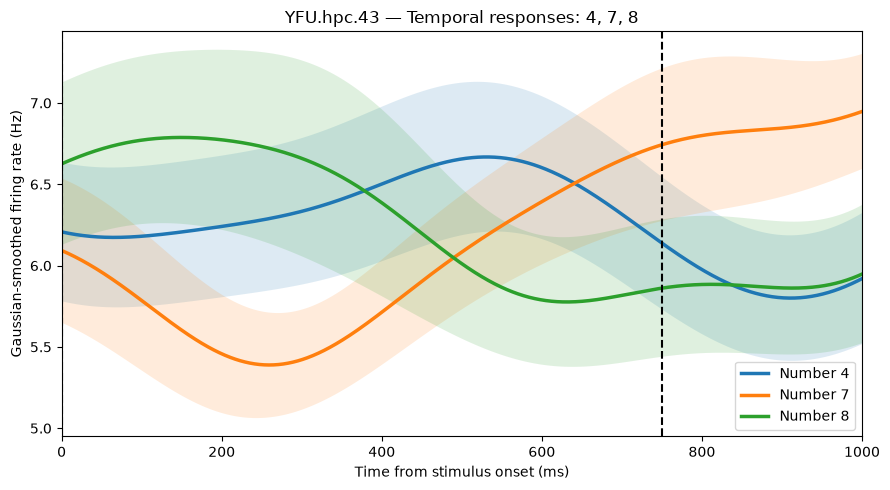

In [115]:
import matplotlib.pyplot as plt

numbers_to_plot = [4, 7, 8]

fig, ax = plt.subplots(figsize=(9, 5))

for number in numbers_to_plot:

    mean = mean_by_number[number]
    sem = sem_by_number[number]

    ax.plot(
        time,
        mean,
        linewidth=2.5,
        label=f"Number {number}"
    )

    ax.fill_between(
        time,
        mean - sem,
        mean + sem,
        alpha=0.15
    )

# Stimulus ON
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

# Stimulus OFF
ax.axvline(
    750,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax.set_xlim(0, 1000)

ax.set_xlabel("Time from stimulus onset (ms)")
ax.set_ylabel("Gaussian-smoothed firing rate (Hz)")

ax.set_title(
    "YFU.hpc.43 — Temporal responses: 4, 7, 8"
)

ax.legend()

plt.tight_layout()
plt.show()

In [123]:
from src.single_neuron_temporal_analysis import analyze_temporal_response

out = analyze_temporal_response("YFU", 43)

KeyError: "Could not identify number/mean columns in tuning table. Columns: ['count', 'mean', 'std', 'sem']"

In [124]:
out = analyze_temporal_response(
    "YFU",
    43,
    grouping="sd"
)

KeyError: "Could not identify number/mean columns in tuning table. Columns: ['count', 'mean', 'std', 'sem']"

In [125]:
from src.firing_rate_tuning import analyze_neuron

test = analyze_neuron(
    "YFU",
    43,
    plot=False,
    verbose=False
)

print(test.keys())
print()
print(test["tuning"].columns)
print()
print(test["tuning"].head())

dict_keys(['subject', 'matlab_row', 'python_row', 'region', 'total_neurons', 'total_mtl_neurons', 'region_counts', 'mtl_region_counts', 'presentations', 'tuning', 'spike_times', 'figure', 'axis'])

Index(['count', 'mean', 'std', 'sem'], dtype='str')

        count      mean       std       sem
number                                     
1          53  6.498952  2.725109  0.374323
2          67  6.766169  2.706018  0.330593
3          52  7.307692  3.003638  0.416530
4          62  6.308244  2.836531  0.360240
5          51  7.189542  2.857547  0.400137


Neuron: YFU.hpc.43
Grouping rule: overlapping mean +/- SEM intervals
Groups: [[1, 2, 3, 4, 5, 6, 7, 8, 9]]
Multi-number overlap groups: [[1, 2, 3, 4, 5, 6, 7, 8, 9]]
Note: interval overlap is descriptive; it is not a statistical equivalence test.


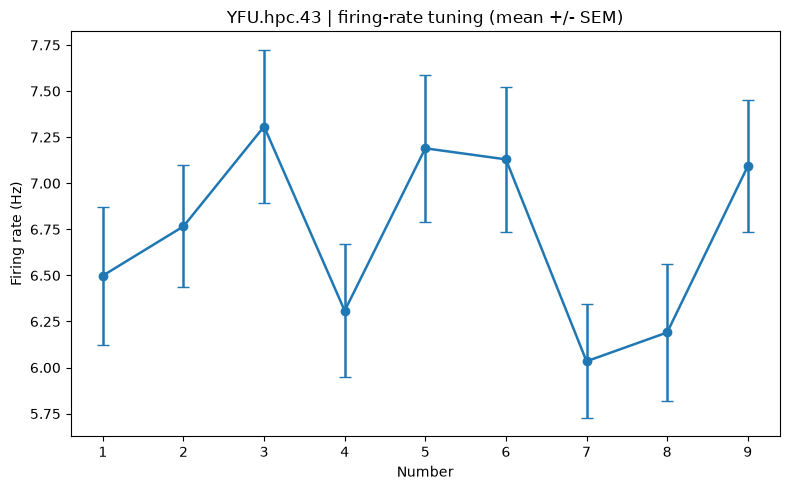

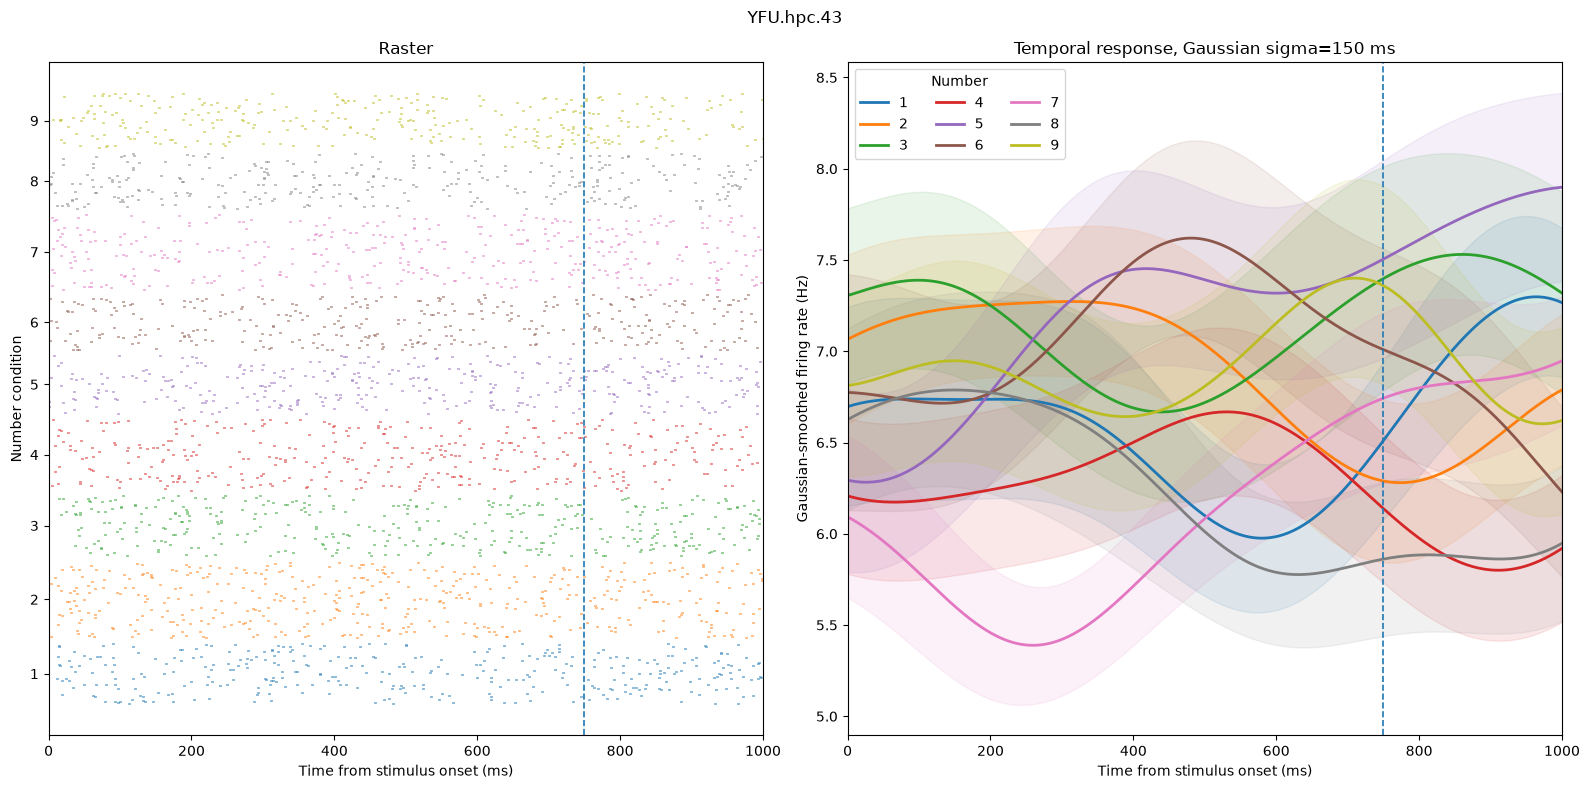

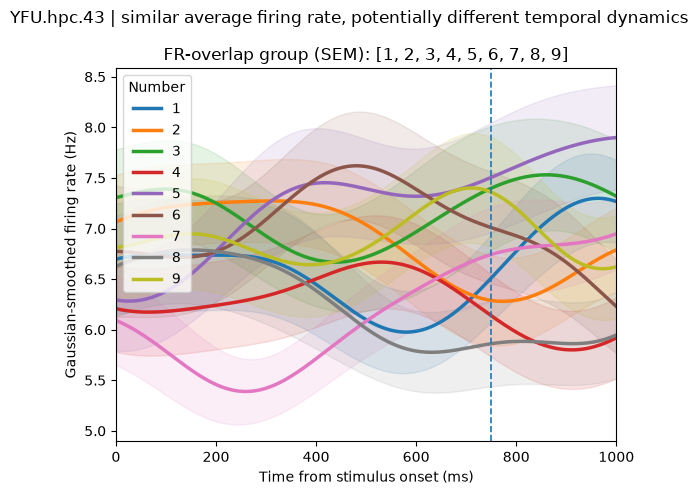

In [127]:
import importlib
import src.single_neuron_temporal_analysis as snta

importlib.reload(snta)

out = snta.analyze_temporal_response("YFU", 43)

Neuron: YFU.hpc.43
MATLAB/paper neuron row: 43
Region: hpc
Selected temporal comparison: (2, 5, 8)
Gaussian sigma: 150 ms


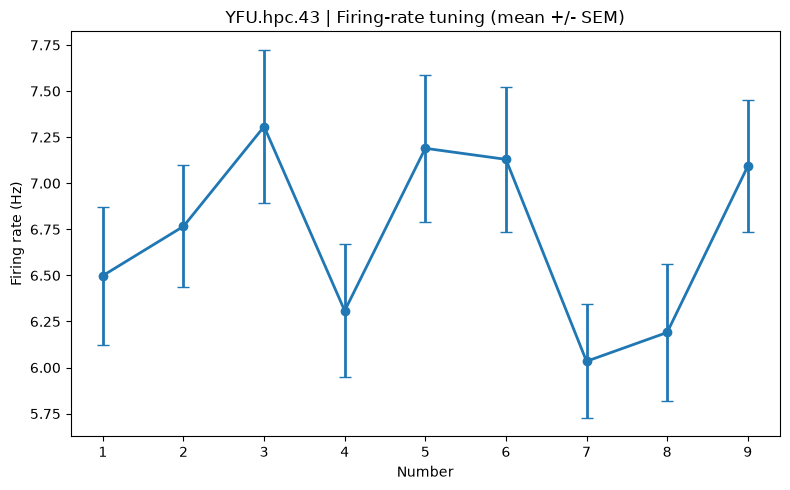

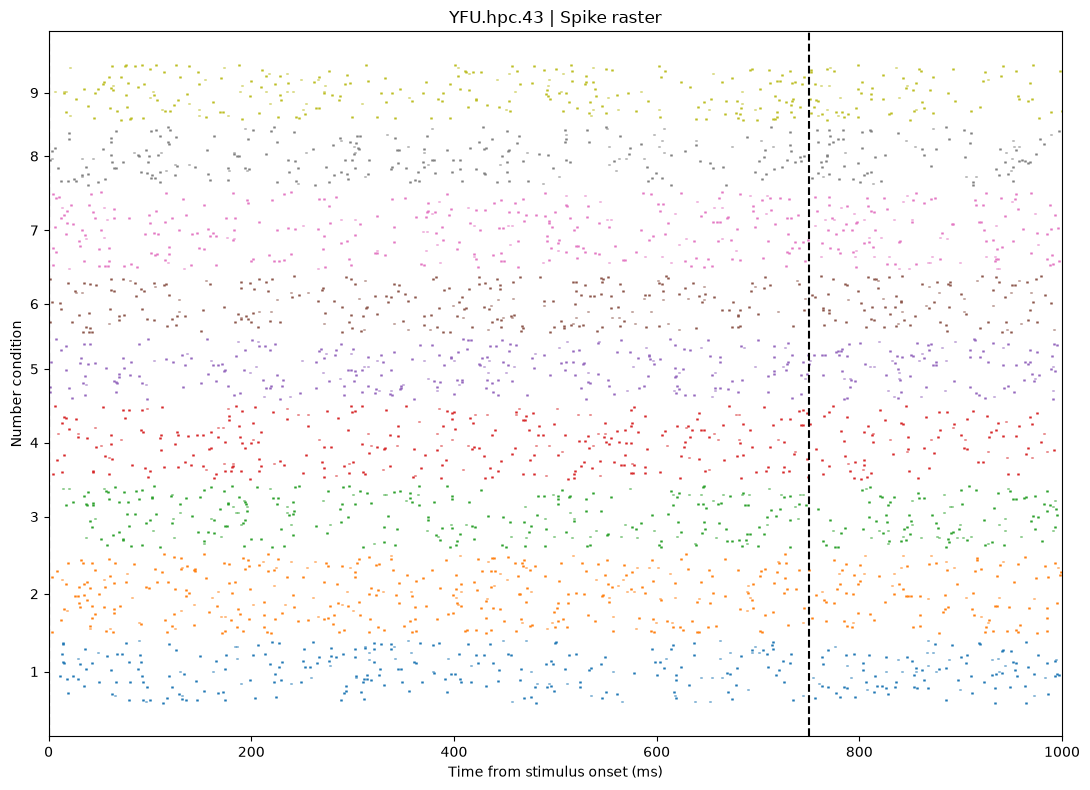

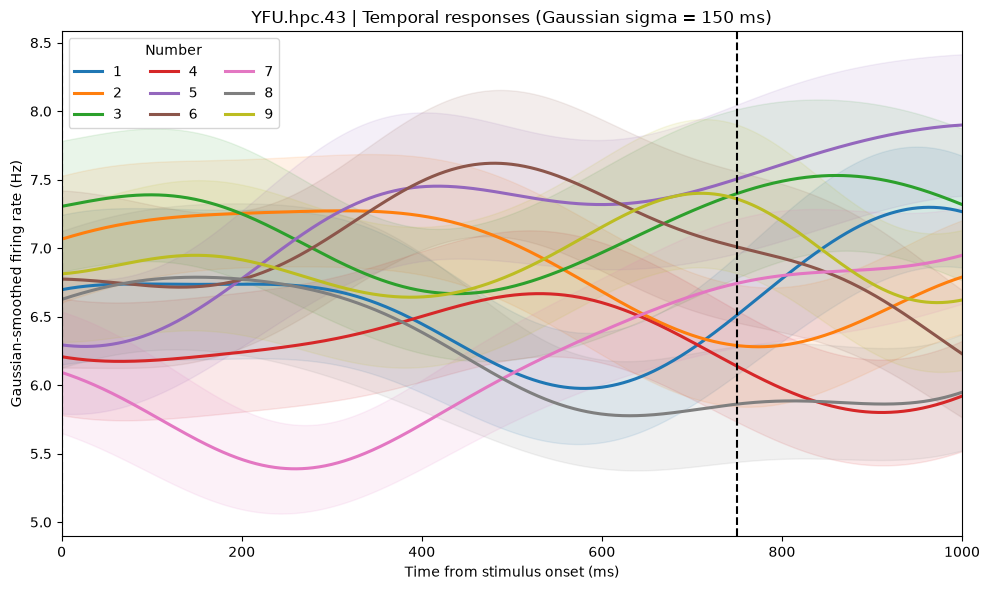

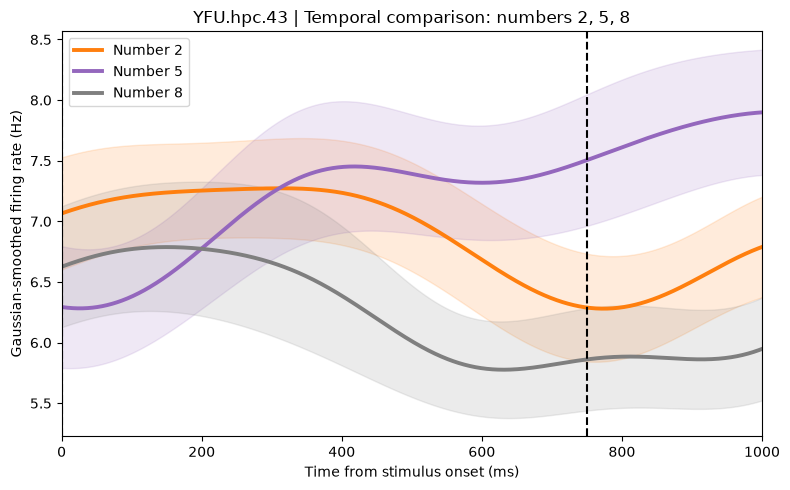

In [128]:
from src.single_neuron_plots import analyze_single_neuron

out = analyze_single_neuron("YFU", 43)

Neuron: YFT.hpc.50
MATLAB/paper neuron row: 50
Region: hpc
Selected temporal comparison: (2, 5, 8)
Gaussian sigma: 150 ms


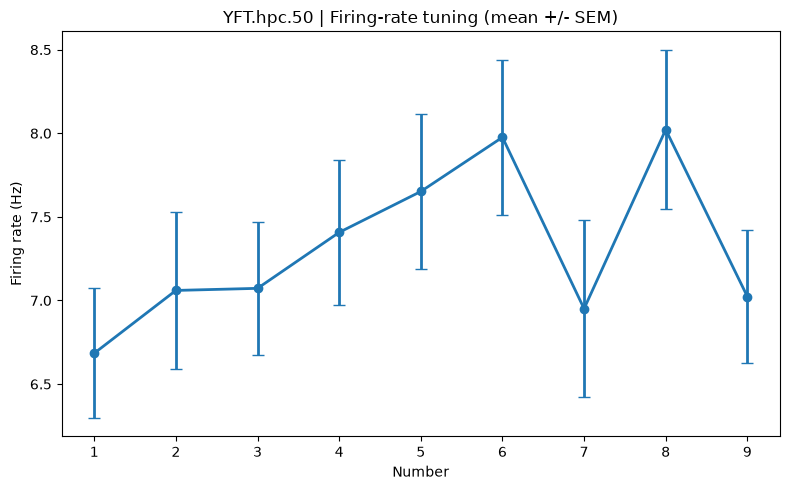

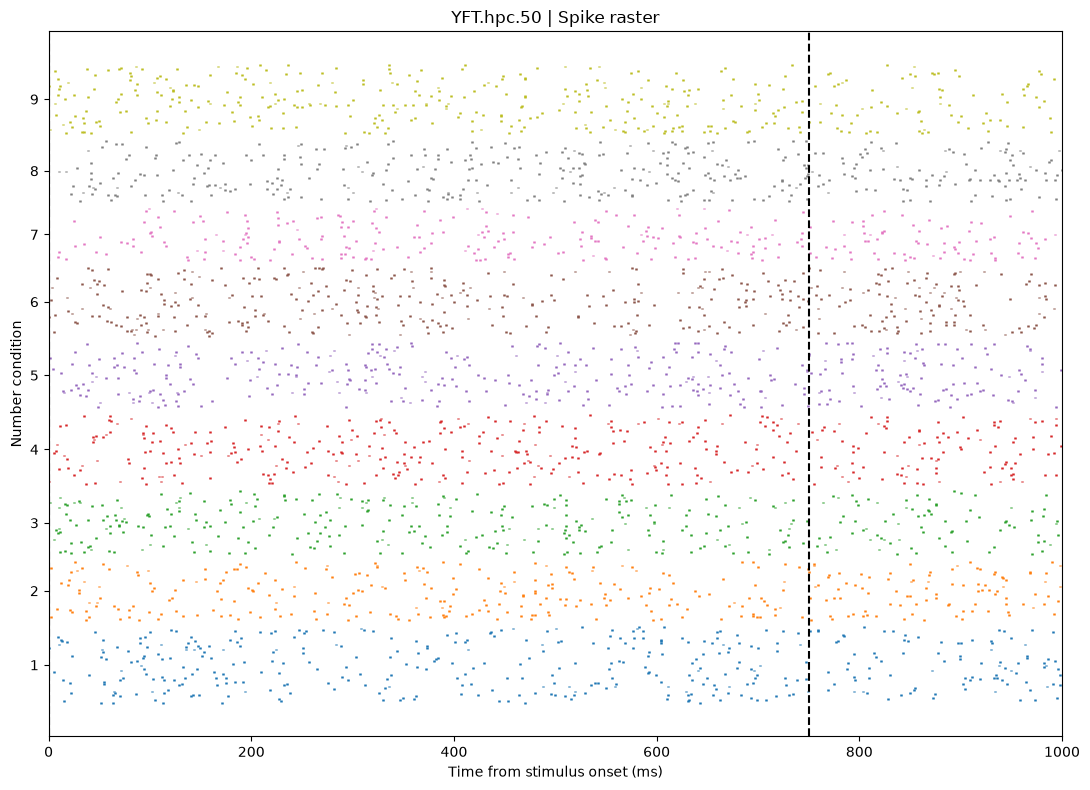

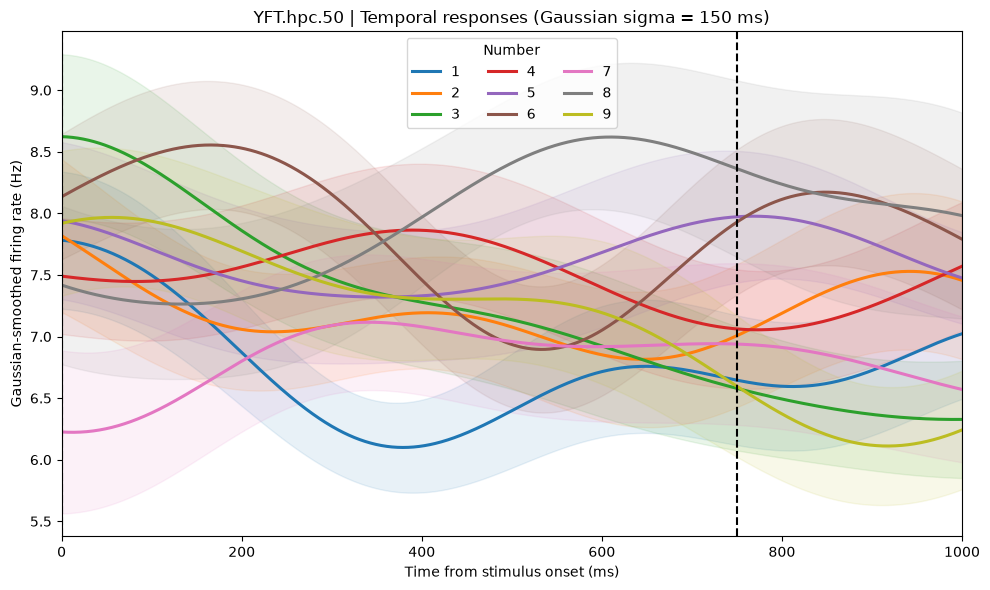

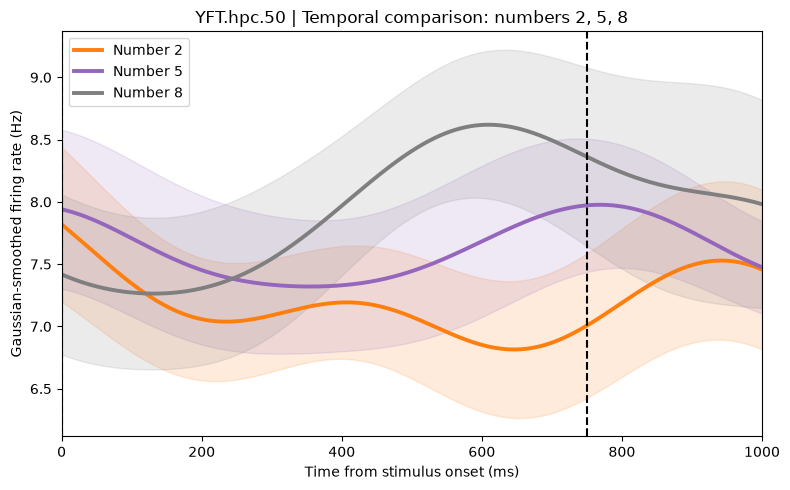

In [129]:
out = analyze_single_neuron("YFT", 50)